### purpose

create figure of environmental values for continuous space simulation by color-coding the loadings of the first three principal component axes of PCA-transformed environmental values.

each of [red, green, blue] gets a value between 0 and 1. This is given based on the relative position of an environment relative to the min and max of each axis

In [1]:
from pythonimports import *
import myfigs as mf

import runtime_API as rt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import rgb2hex
import seaborn as sns

figdir = makedir(f'{rt.resdir}/figures/07_continuous_space_sims/03_env_PCA_map')

t0 = dt.now()

rt.latest_commit()
session_info.show()

#########################################################
Today:	January 27, 2025 - 11:15:16 EST
python version: 3.8.5
conda env: mvp_env

Current commit of pythonimports:
commit 6a767410e7b569adbf9df526de108f22ef50aad8  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Wed Mar 6 13:42:13 2024 -0700

Current commit of MVP_offsets:
commit 5ce82f4d655645237a0f4026fa32e220226dc373  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Thu May 16 13:02:58 2024 -0400

Current commit of MVP_runtime:
commit a98ef38f88b81d808c334e87d0c6392e142941da  
Merge: 50cf2c9 cc54cc3  
Author: Brandon Lind <lind.brandon.m@gmail.com>
#########################################################



In [2]:
bioclim_data = pd.read_table('/work/lotterhos/MVP-NonClinalAF/multipheno_multienvi/bioclim/adaptive_env.txt',
                            delim_whitespace=True)#.reset_index(drop=True)

idx = bioclim_data.index.tolist()

random.shuffle(idx)

bioclim_data = bioclim_data.loc[idx].reset_index(drop=True)

# .sort_values(by=['slim_x', 'slim_y'])

bioclim_data

,x,y,MAT,MTWetQ,MTDQ,PWM,PDM,PWarmQ,slim_x,slim_y
0,-118.522,51.175,-0.722527,-1.139545,0.008424,1.009826,1.041339,0.121008,0.557080,0.359254
1,-119.573,52.981,0.470892,-0.982111,0.790832,-0.393889,0.307813,-0.215543,0.431707,0.877475
2,-121.231,51.894,0.271989,-0.929633,0.605525,-0.063603,0.226310,0.121008,0.233926,0.565567
3,-119.222,51.874,-0.523624,-1.129050,0.152551,0.349254,0.715328,0.121008,0.473577,0.559828
4,-119.246,52.059,-0.404282,-1.118554,0.234910,0.349254,0.715328,0.226180,0.470715,0.612912
...,...,...,...,...,...,...,...,...,...,...
129595,-120.437,50.874,0.948260,1.274450,0.111372,-1.673746,-1.077736,-1.456574,0.328641,0.272884
129596,-116.911,50.010,2.062118,-0.404851,3.467494,1.133683,0.796830,-0.678300,0.749254,0.024964
129597,-119.246,51.476,-0.006475,-1.013598,0.440807,0.266683,0.552322,-0.089336,0.470715,0.445624
129598,-121.768,51.884,1.226725,1.389902,0.234910,-1.095746,-1.159239,-0.825541,0.169868,0.562697


In [3]:
envs = [col for col in bioclim_data if col not in ['x', 'y', 'slim_x', 'slim_y']]

envs

['MAT', 'MTWetQ', 'MTDQ', 'PWM', 'PDM', 'PWarmQ']

In [4]:
# standardize env data
envdata_std = pd.DataFrame(StandardScaler().fit_transform(bioclim_data[envs]),
                           index=bioclim_data.index, columns=envs)

envdata_std

,MAT,MTWetQ,MTDQ,PWM,PDM,PWarmQ
0,-0.722530,-1.139550,0.008424,1.009830,1.041343,0.121009
1,0.470894,-0.982115,0.790835,-0.393890,0.307814,-0.215544
2,0.271990,-0.929636,0.605527,-0.063603,0.226311,0.121009
3,-0.523626,-1.129054,0.152552,0.349256,0.715330,0.121009
4,-0.404283,-1.118558,0.234911,0.349256,0.715330,0.226181
...,...,...,...,...,...,...
129595,0.948264,1.274455,0.111372,-1.673753,-1.077740,-1.456580
129596,2.062126,-0.404853,3.467507,1.133688,0.796834,-0.678303
129597,-0.006475,-1.013602,0.440809,0.266684,0.552324,-0.089336
129598,1.226729,1.389907,0.234911,-1.095750,-1.159244,-0.825545


In [5]:
# get PCA loadings
pca = PCA(n_components=3)
loadings_array = pca.fit_transform(envdata_std)
loadings = pd.DataFrame(loadings_array, index=envdata_std.index)

loadings

,0,1,2
0,-1.833551,0.485302,-0.400593
1,-0.056822,1.267635,-0.291959
2,-0.378098,0.895905,-0.089951
3,-1.238029,0.535037,-0.561734
4,-1.228892,0.583974,-0.430812
...,...,...,...
129595,2.869586,0.158927,-0.301082
129596,-0.057050,3.737548,2.048414
129597,-0.777994,0.911518,-0.272832
129598,2.514990,0.024412,0.512991


In [6]:
# get rbg colors by converting loadings into values >= 0 and <= 1
colors = loadings.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

colors

,0,1,2
0,0.220180,0.449611,0.298811
1,0.434236,0.551657,0.314745
2,0.395530,0.503169,0.344375
3,0.291927,0.456098,0.275176
4,0.293028,0.462481,0.294379
...,...,...,...
129595,0.786803,0.407039,0.313407
129596,0.434209,0.873831,0.658024
129597,0.347351,0.505206,0.317551
129598,0.744082,0.389493,0.432813


In [7]:
bioclim_data['rgb'] = colors.apply(tuple, axis=1)

bioclim_data

,x,y,MAT,MTWetQ,MTDQ,PWM,PDM,PWarmQ,slim_x,slim_y,rgb
0,-118.522,51.175,-0.722527,-1.139545,0.008424,1.009826,1.041339,0.121008,0.557080,0.359254,"(0.22018036901215707, 0.4496107138078647, 0.29..."
1,-119.573,52.981,0.470892,-0.982111,0.790832,-0.393889,0.307813,-0.215543,0.431707,0.877475,"(0.43423623552851065, 0.551657474834053, 0.314..."
2,-121.231,51.894,0.271989,-0.929633,0.605525,-0.063603,0.226310,0.121008,0.233926,0.565567,"(0.3955297198965452, 0.503169377300326, 0.3443..."
3,-119.222,51.874,-0.523624,-1.129050,0.152551,0.349254,0.715328,0.121008,0.473577,0.559828,"(0.291927385240316, 0.4560980221229841, 0.2751..."
4,-119.246,52.059,-0.404282,-1.118554,0.234910,0.349254,0.715328,0.226180,0.470715,0.612912,"(0.29302819253303175, 0.46248140824662154, 0.2..."
...,...,...,...,...,...,...,...,...,...,...,...
129595,-120.437,50.874,0.948260,1.274450,0.111372,-1.673746,-1.077736,-1.456574,0.328641,0.272884,"(0.7868027073207222, 0.4070386841018072, 0.313..."
129596,-116.911,50.010,2.062118,-0.404851,3.467494,1.133683,0.796830,-0.678300,0.749254,0.024964,"(0.4342088427013808, 0.8738306432612045, 0.658..."
129597,-119.246,51.476,-0.006475,-1.013598,0.440807,0.266683,0.552322,-0.089336,0.470715,0.445624,"(0.347351224132601, 0.5052058690321339, 0.3175..."
129598,-121.768,51.884,1.226725,1.389902,0.234910,-1.095746,-1.159239,-0.825541,0.169868,0.562697,"(0.7440818061895076, 0.38949255514025144, 0.43..."


Saved to:  /work/lotterhos/brandon/runtime/figures/07_continuous_space_sims/03_env_PCA_map/pca_map.pdf


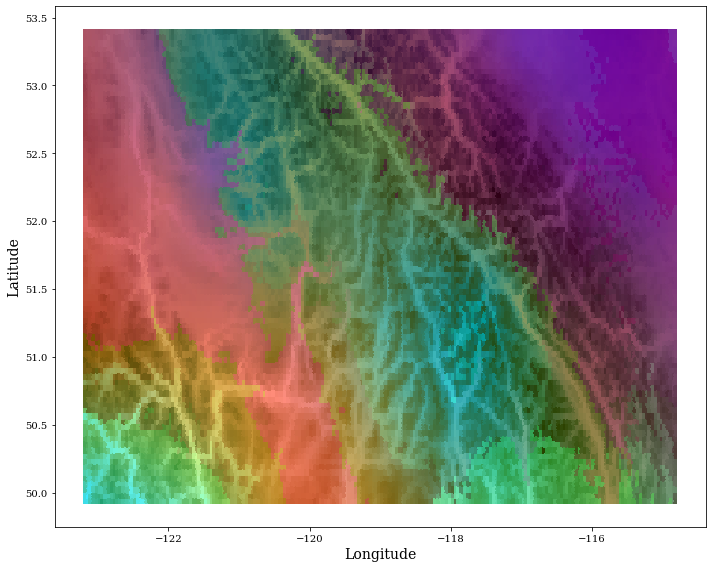

In [8]:
plotdata = bioclim_data.reset_index()

g = sns.scatterplot(
    data=plotdata, x='x', y='y', hue='index', palette=bioclim_data['rgb'].to_dict(),
    legend=False, 
    s=4,
    alpha=1, marker='s', edgecolor='none',
)

g.figure.set_size_inches((10, 8))
g.axes.set_xlabel('Longitude', fontsize=14)
g.axes.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()

mf.save_pdf(f'{figdir}/pca_map.pdf')

plt.show()

In [9]:
formatclock(dt.now() - t0)

'0-00:00:12'